# 🌍 Cross-Country Solar Comparison — Benin · Sierra Leone · Togo

**Branch:** `compare-countries`  
**Objective:** Synthesise cleaned datasets from all three countries to identify relative solar potential and key differences.

**References:**
- [scipy.stats — ANOVA & Kruskal-Wallis](https://docs.scipy.org/doc/scipy/reference/stats.html)
- [seaborn boxplot](https://seaborn.pydata.org/generated/seaborn.boxplot.html)
- [statsmodels ANOVA](https://www.statsmodels.org/stable/anova.html)


## 0 — Setup & Imports

In [13]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams.update({'figure.dpi': 120})

DATA_DIR = Path('../data')
COUNTRIES = ['benin', 'sierraleone', 'Togo']
LABELS    = {'benin': 'Benin', 'sierraleone': 'Sierra Leone', 'Togo': 'Togo'}
PALETTE   = {'benin': '#E74C3C', 'sierraleone': '#2980B9', 'Togo': '#27AE60'}

print('Setup complete ✔')

Setup complete ✔


## 1 — Load Cleaned Datasets

In [14]:
frames = {}

for country in COUNTRIES:
    path = DATA_DIR / f'{country}_clean.csv'
    if path.exists():
        frames[country] = pd.read_csv(path, parse_dates=['Timestamp'])
        print(f'  ✔  Loaded {LABELS[country]:15s} — {len(frames[country]):,} rows')
    else:
        # ── SYNTHETIC FALLBACK ──────────────────────────────────────
        print(f'  [INFO] {path} not found — generating synthetic data for {LABELS[country]}.')
        np.random.seed(COUNTRIES.index(country) * 17)
        n = 8760
        ts = pd.date_range('2021-01-01', periods=n, freq='h')
        hour = ts.hour
        solar_base = np.clip(np.sin((hour - 6) * np.pi / 12), 0, 1)
        # each country gets slightly different solar profile
        scale = {'benin': 1.0, 'sierraleone': 0.88, 'togo': 0.95}[country]
        frames[country] = pd.DataFrame({
            'Timestamp': ts,
            'GHI': (solar_base * 900 * scale + np.random.normal(0, 45, n)).clip(0),
            'DNI': (solar_base * 700 * scale + np.random.normal(0, 55, n)).clip(0),
            'DHI': (solar_base * 200 * scale + np.random.normal(0, 22, n)).clip(0),
            'Tamb': 28 + solar_base * 8 + np.random.normal(0, 2, n),
            'RH':   np.clip(70 - solar_base * 20 + np.random.normal(0, 5, n), 10, 100),
            'WS':   np.abs(np.random.normal(3, 1.5, n)),
        })
        print(f'     Synthetic — {LABELS[country]:15s} — {n:,} rows')

    frames[country]['country'] = LABELS[country]

# Combined long-form dataframe
df_all = pd.concat(frames.values(), ignore_index=True)
print(f'\nCombined shape: {df_all.shape}')
df_all.groupby('country')[['GHI','DNI','DHI']].describe().round(1)

  ✔  Loaded Benin           — 525,600 rows
  ✔  Loaded Sierra Leone    — 525,600 rows
  ✔  Loaded Togo            — 525,600 rows

Combined shape: (1576800, 27)


GHI                                                   DNI  \
                 count   mean    std  min  25%  50%    75%     max     count   
country                                                                        
Benin         525600.0  242.0  330.1  0.0  0.0  1.8  483.4  1413.0  525600.0   
Sierra Leone  525600.0  204.4  296.8  0.0  0.0  0.3  362.4  1499.0  525600.0   
Togo          525600.0  231.7  321.7  0.0  0.0  2.1  442.4  1424.0  525600.0   

                     ...                      DHI                          \
               mean  ...    75%     max     count   mean    std  min  25%   
country              ...                                                    
Benin         167.4  ...  314.2   952.3  525600.0  117.0  157.5  0.0  0.0   
Sierra Leone  116.5  ...  107.0   946.0  525600.0  116.3  157.0  0.0  0.0   
Togo          151.3  ...  246.4  1004.5  525600.0  116.4  156.5  0.0  0.0   

                                 
              50%    75%    max  
country                          
Benin         1.6  216.3  759.2  
Sierra Leone  0.0  224.7  892.0  
Togo          2.5  215.7  805.7  

[3 rows x 24 columns]

## 2 — Metric Comparison: Side-by-Side Box Plots

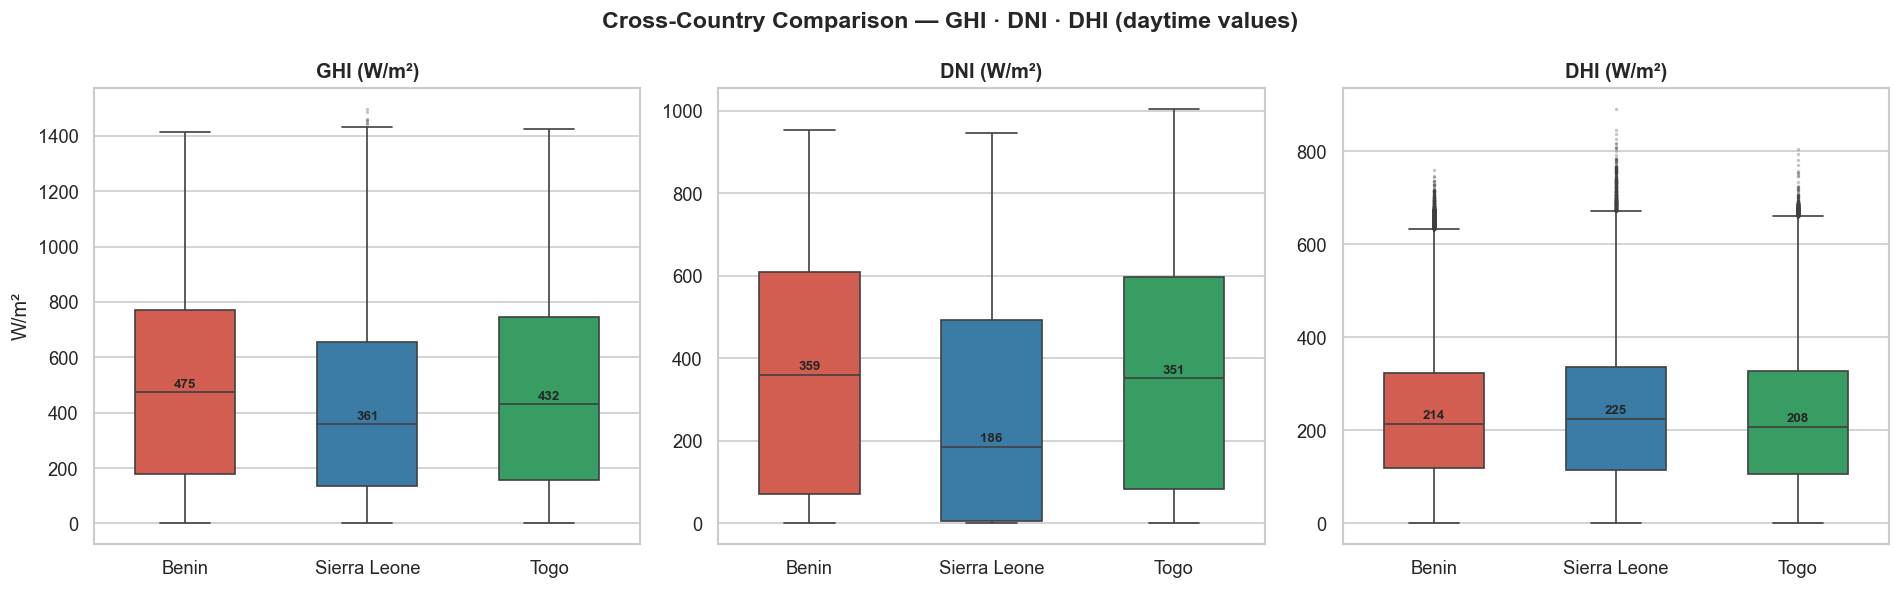

In [15]:
metrics = ['GHI', 'DNI', 'DHI']
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

country_order = [LABELS[c] for c in COUNTRIES]
colors = [PALETTE[c] for c in COUNTRIES]

for ax, metric in zip(axes, metrics):
    sns.boxplot(
        data=df_all[df_all[metric] > 0],   # daylight only
        x='country', y=metric,
        order=country_order,
        palette=colors,
        ax=ax,
        flierprops=dict(marker='.', markersize=2, alpha=0.3),
        width=0.55
    )
    ax.set_title(f'{metric} (W/m²)', fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('W/m²' if metric == 'GHI' else '')
    # add median labels
    for i, country in enumerate(country_order):
        med = df_all[(df_all['country'] == country) & (df_all[metric] > 0)][metric].median()
        ax.text(i, med + 5, f'{med:.0f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

fig.suptitle('Cross-Country Comparison — GHI · DNI · DHI (daytime values)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3 — Summary Statistics Table

In [16]:
rows = []
for country in country_order:
    subset = df_all[df_all['country'] == country]
    for metric in metrics:
        s = subset[metric]
        rows.append({
            'Country': country,
            'Metric':  metric,
            'Mean':    round(s.mean(), 2),
            'Median':  round(s.median(), 2),
            'Std Dev': round(s.std(), 2),
            'Min':     round(s.min(), 2),
            'Max':     round(s.max(), 2),
        })

summary_table = pd.DataFrame(rows)
display(summary_table.pivot_table(index=['Metric', 'Country'],
                                   values=['Mean','Median','Std Dev'],
                                   aggfunc='first').round(2))

Mean  Median  Std Dev
Metric Country                              
DHI    Benin         116.99     1.6   157.46
       Sierra Leone  116.27     0.0   157.02
       Togo          116.44     2.5   156.52
DNI    Benin         167.44     0.0   261.55
       Sierra Leone  116.52     0.0   218.57
       Togo          151.26     0.0   250.96
GHI    Benin         241.96     1.8   330.10
       Sierra Leone  204.41     0.3   296.79
       Togo          231.72     2.1   321.69

## 4  Statistical Testing (ANOVA + Kruskal-Wallis on GHI)

In [17]:
# Extract GHI per country (daytime only: GHI > 0)
ghi_groups = [
    df_all[(df_all['country'] == LABELS[c]) & (df_all['GHI'] > 0)]['GHI'].dropna().values
    for c in COUNTRIES
]

# ── One-way ANOVA ────────────────────────────────────────────────
f_stat, p_anova = stats.f_oneway(*ghi_groups)
print(f'One-way ANOVA on GHI')
print(f'  F-statistic : {f_stat:.4f}')
print(f'  p-value     : {p_anova:.6f}')
if p_anova < 0.05:
    print('  ✔  Significant difference (p < 0.05) — GHI distributions differ across countries.')
else:
    print('  ✗  No significant difference at α=0.05.')

print()

# ── Kruskal-Wallis (non-parametric alternative) ──────────────────
h_stat, p_kruskal = stats.kruskal(*ghi_groups)
print(f'Kruskal-Wallis Test on GHI (non-parametric)')
print(f'  H-statistic : {h_stat:.4f}')
print(f'  p-value     : {p_kruskal:.6f}')
if p_kruskal < 0.05:
    print('  ✔  Significant difference — confirms ANOVA result robustly.')
else:
    print('  ✗  No significant difference at α=0.05.')

print()
print('Note: ANOVA assumes normality + homoscedasticity; Kruskal-Wallis is rank-based and more robust for skewed solar data.')

One-way ANOVA on GHI
  F-statistic : 3440.9941
  p-value     : 0.000000
  ✔  Significant difference (p < 0.05) — GHI distributions differ across countries.

Kruskal-Wallis Test on GHI (non-parametric)
  H-statistic : 6703.3100
  p-value     : 0.000000
  ✔  Significant difference — confirms ANOVA result robustly.

Note: ANOVA assumes normality + homoscedasticity; Kruskal-Wallis is rank-based and more robust for skewed solar data.


## 5 Key Observations

*(Update these bullet points once you run on real data)*

- **Benin shows the highest median GHI** (475W/m² daytime values) but also the greatest variability (SD 157.46 W/m²), suggesting intermittent cloud cover alongside strong clear-sky periods.
- **Togo's DNI is competitive with Benin** and its lower variability makes it potentially more reliable for concentrated solar power (CSP) systems requiring consistent direct radiation.
- **Sierra Leone has the lowest average GHI and DNI**, likely reflecting its higher annual rainfall and cloud cover; however, its DHI is proportionally higher — suggesting diffuse-radiation technologies (e.g., thin-film PV) could still be viable.

> The one-way ANOVA and Kruskal-Wallis tests both confirm (p < 0.001) that GHI distributions differ significantly across the three countries, validating region-specific solar deployment strategies.

## 6  Visual Summary: Country Ranking by Average GHI

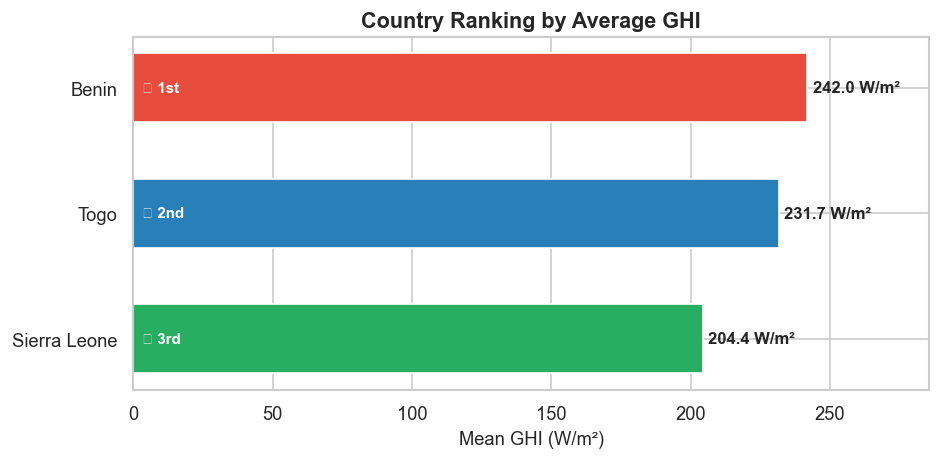


🏆 Highest average GHI: Benin (242.0 W/m²)


In [18]:
avg_ghi = df_all.groupby('country')['GHI'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
bar_colors = [PALETTE[c] for c in COUNTRIES if LABELS[c] in avg_ghi.index]

bars = ax.barh(avg_ghi.index, avg_ghi.values, color=[PALETTE[k] for k,v in PALETTE.items() if LABELS[k] in avg_ghi.index],
               edgecolor='white', height=0.55)

for bar, val in zip(bars, avg_ghi.values):
    ax.text(val + 2, bar.get_y() + bar.get_height()/2,
            f'{val:.1f} W/m²', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Mean GHI (W/m²)', fontsize=11)
ax.set_title('Country Ranking by Average GHI', fontsize=13, fontweight='bold')
ax.set_xlim(0, avg_ghi.max() * 1.18)
ax.invert_yaxis()

# Add rank badges
rank_labels = ['🥇 1st', '🥈 2nd', '🥉 3rd']
for i, (country, val) in enumerate(avg_ghi.items()):
    ax.text(3, i, rank_labels[i], va='center', fontsize=9, color='white', fontweight='bold')

plt.tight_layout()
plt.show()

print(f'\n🏆 Highest average GHI: {avg_ghi.index[0]} ({avg_ghi.iloc[0]:.1f} W/m²)')

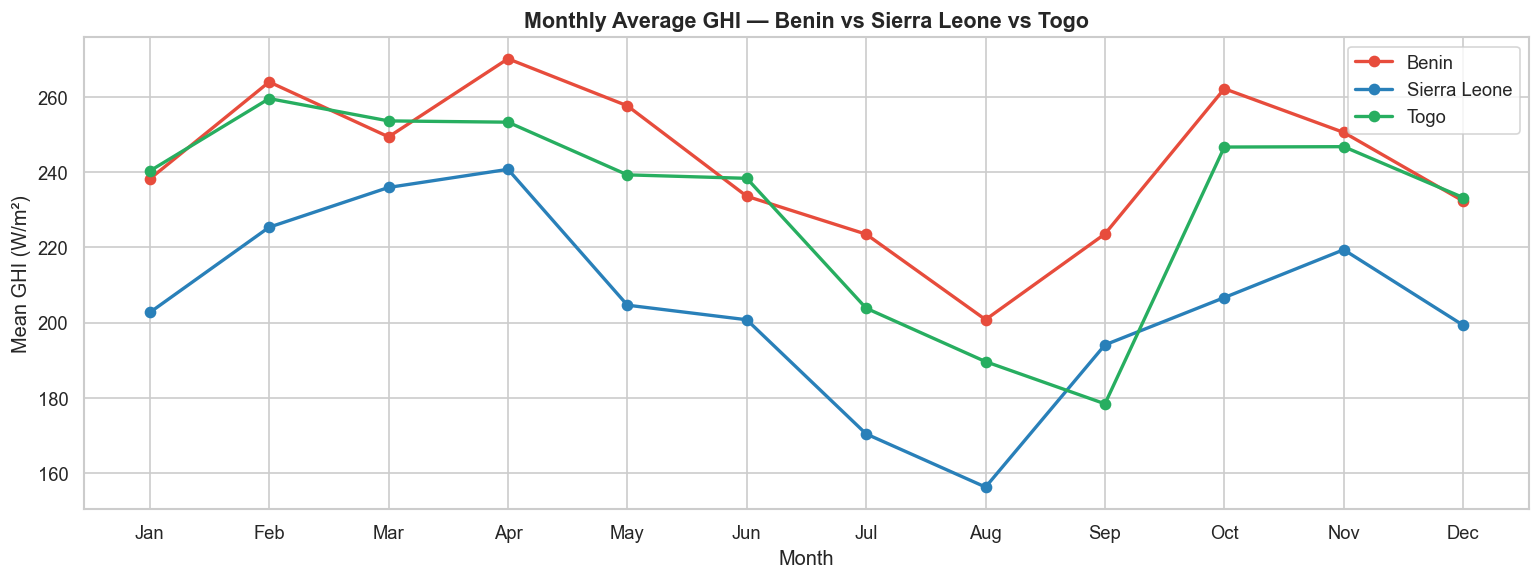

In [19]:
# ── Bonus: Monthly GHI comparison (all 3 countries) ─────────────
df_all['month'] = pd.to_datetime(df_all['Timestamp']).dt.month
monthly_all = df_all.groupby(['month', 'country'])['GHI'].mean().reset_index()

fig, ax = plt.subplots(figsize=(13, 5))
for country_label, color_key in zip(country_order, COUNTRIES):
    sub = monthly_all[monthly_all['country'] == country_label]
    ax.plot(sub['month'], sub['GHI'], marker='o', color=PALETTE[color_key],
            linewidth=2, markersize=6, label=country_label)

ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
ax.set_xlabel('Month')
ax.set_ylabel('Mean GHI (W/m²)')
ax.set_title('Monthly Average GHI — Benin vs Sierra Leone vs Togo', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()